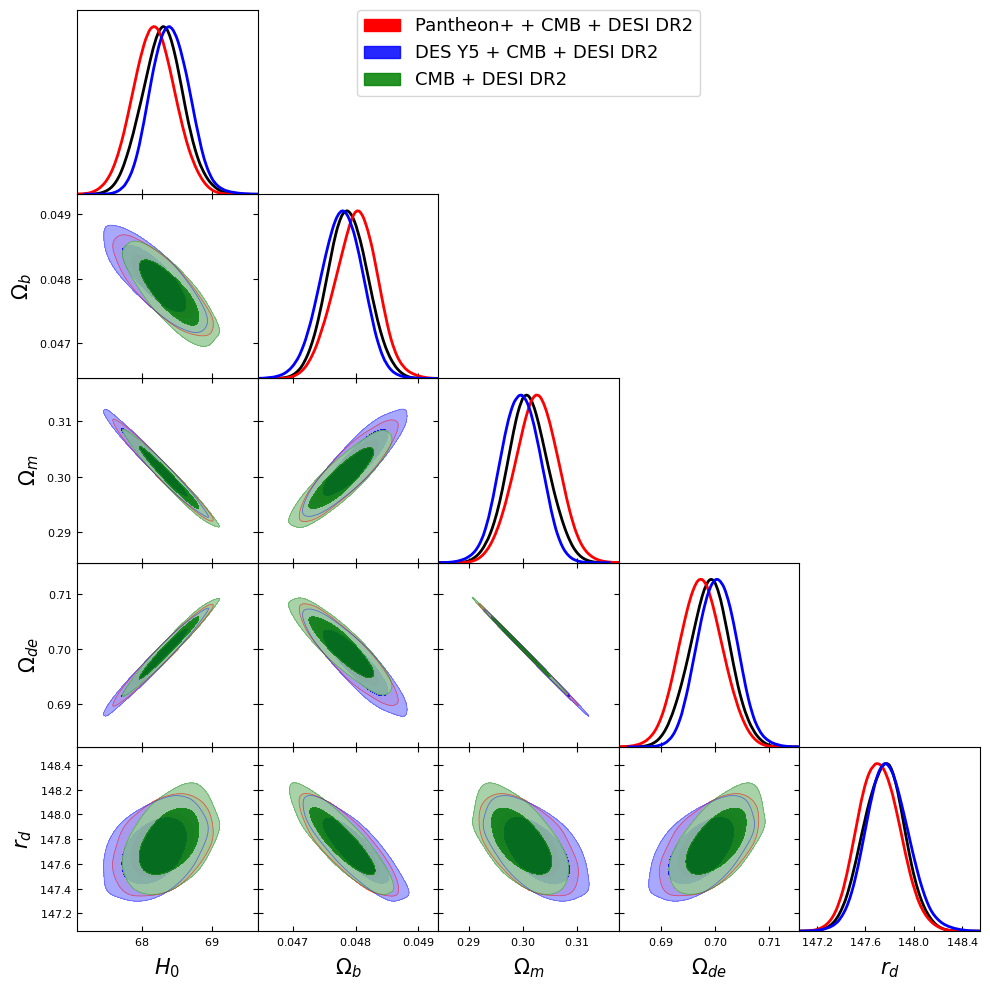


 ΛCDM Information Criteria

Pantheon+ + CMB + DESI DR2
chi2_min = 1419.939
AIC      = 1427.939
BIC      = 1449.725

DES Y5 + CMB + DESI DR2
chi2_min = 1663.824
AIC      = 1671.824
BIC      = 1693.899

CMB + DESI DR2
chi2_min = 13.891
AIC      = 21.891
BIC      = 24.151

Parameter constraints for Pantheon+ + CMB + DESI DR2:
H_0 = 68.29\pm 0.29
\Omega_b = 0.04788\pm 0.00032
\Omega_m = 0.3010\pm 0.0038
\Omega_{de} = 0.6990\pm 0.0038

Parameter constraints for DES Y5 + CMB + DESI DR2:
H_0 = 68.17\pm 0.31
\Omega_b = 0.04800^{+0.00036}_{-0.00032}
\Omega_m = 0.3026\pm 0.0040
\Omega_{de} = 0.6974\pm 0.0040

Parameter constraints for CMB + DESI DR2:
H_0 = 68.40\pm 0.28
\Omega_b = 0.04778\pm 0.00033
\Omega_m = 0.2996\pm 0.0036
\Omega_{de} = 0.7004\pm 0.0036


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ============================================================
# 1. Load samples
# ============================================================

path_prefix = (
    "/Users/prasantasahoo/Documents/cobaya_project/"
    "lcdm/chains/lcdm/lcdm_"
)

samples1 = loadMCSamples(path_prefix + "set1_PP_CMB_DESI", settings={'ignore_rows': 0.3})
samples2 = loadMCSamples(path_prefix + "set2_DESY5_CMB_DESI", settings={'ignore_rows': 0.3})
samples3 = loadMCSamples(path_prefix + "set3_CMB_DESI", settings={'ignore_rows': 0.3})

samples_list = [samples1, samples2, samples3]

labels = [
    "Pantheon+ + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

# ============================================================
# 2. Triangle plot
# ============================================================

params = ["H0", "Omegab0", "Omegam0", "Ode0", "rd"]

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_lcdm_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 3. Robust chi-square extraction
# ============================================================

def get_chi2_min(samples):
    p = samples.getParams()

    if hasattr(p, "chi2"):
        return np.min(p.chi2)

    elif hasattr(p, "minusloglike"):
        return 2.0 * np.min(p.minusloglike)

    elif hasattr(p, "minuslogpost"):
        return 2.0 * np.min(p.minuslogpost)

    else:
        raise RuntimeError(
            "No chi2-like quantity found in chain.\n"
            "Inspect with: samples.getParams().getParamNames().list()"
        )

# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_lcdm = 4   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "Pantheon+ + CMB + DESI DR2": 1701 + 0 + 13,   # 1717
    "DES Y5 + CMB + DESI DR2":   1829 + 0 + 13,   # 1845
    "CMB + DESI DR2":            0 + 13           # 16
}

# ============================================================
# 5. Compute chi2_min, AIC, BIC
# ============================================================

print("\n==============================================")
print(" ΛCDM Information Criteria")
print("==============================================")

results = []

for s, label in zip(samples_list, labels):

    chi2_min = get_chi2_min(s)
    # chi2_min = np.min(samples.getParams().chi2)
    # print(chi2_min)
    N = N_values[label]

    AIC = chi2_min + 2 * k_lcdm
    BIC = chi2_min + k_lcdm * np.log(N)

    results.append((label, chi2_min, AIC, BIC))

    print(f"\n{label}")
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")

# ============================================================
# 6. Save results to files
# ============================================================

# ---- Text file ----
with open("lcdm_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("lcdm_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================

for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('H0', limit=1))
    print(s.getInlineLatex('Omegab0', limit=1))
    print(s.getInlineLatex('Omegam0', limit=1))
    print(s.getInlineLatex('Ode0', limit=1))


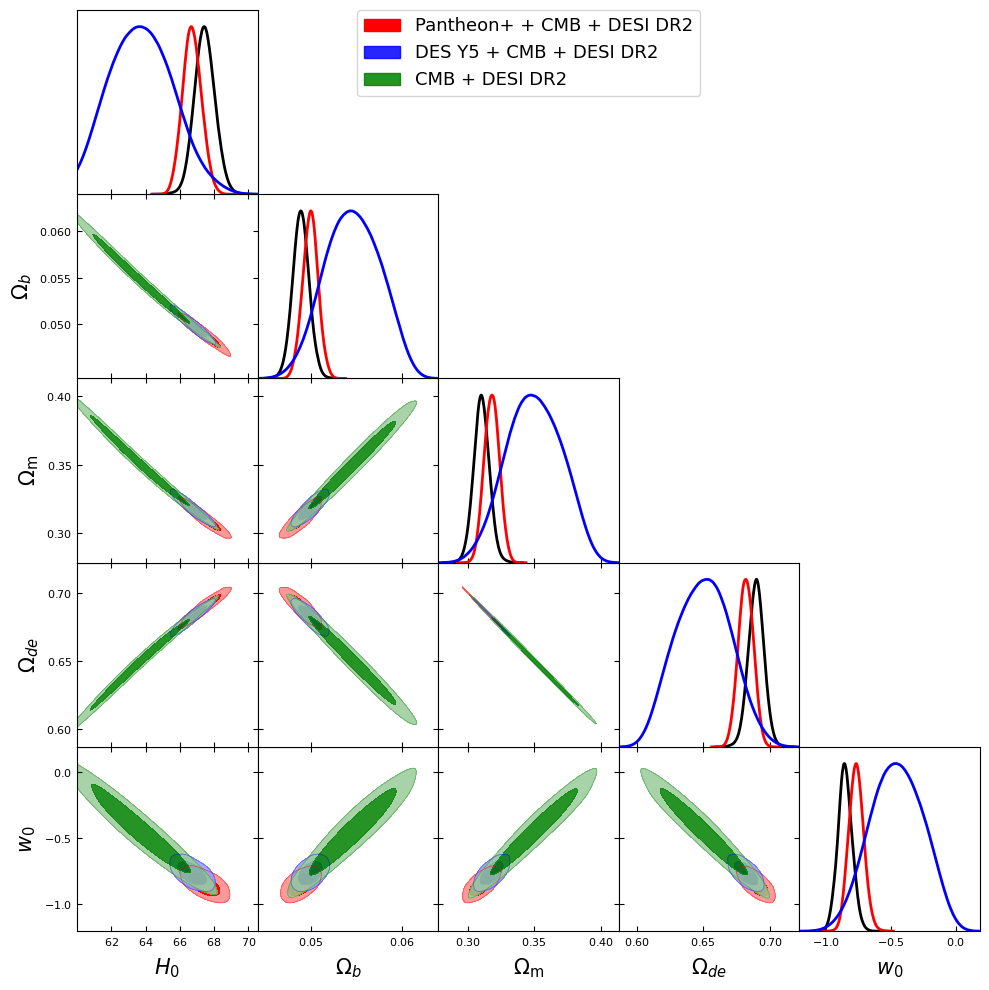


 ΛCDM Information Criteria

Pantheon+ + CMB + DESI DR2
chi2_min = 1412.869
AIC      = 1422.869
BIC      = 1450.102

DES Y5 + CMB + DESI DR2
chi2_min = 1646.292
AIC      = 1656.292
BIC      = 1683.885

CMB + DESI DR2
chi2_min = 7.091
AIC      = 17.091
BIC      = 19.916

 Bayesian Evidence & Bayes Factor (ln Z)
Pantheon+ + CMB + DESI DR2: ln(Z) = -727.209
DES Y5 + CMB + DESI DR2: ln(Z) = -843.950
CMB + DESI DR2: ln(Z) = -21.714

Parameter constraints for Pantheon+ + CMB + DESI DR2:
H_0 = 67.46\pm 0.61
\Omega_b = 0.04893\pm 0.00091
\Omega_\mathrm{m} = 0.3105\pm 0.0059
\Omega_{de} = 0.6895\pm 0.0059
w_{0} = -0.852\pm 0.055

Parameter constraints for DES Y5 + CMB + DESI DR2:
H_0 = 66.72\pm 0.55
\Omega_b = 0.04997\pm 0.00085
\Omega_\mathrm{m} = 0.3181\pm 0.0056
\Omega_{de} = 0.6819\pm 0.0056
w_{0} = -0.766\pm 0.058

Parameter constraints for CMB + DESI DR2:
H_0 = 63.8^{+1.7}_{-2.1}
\Omega_b = 0.0546\pm 0.0030
\Omega_\mathrm{m} = 0.350\pm 0.021
\Omega_{de} = 0.650\pm 0.021
w_{0} = -0.45\pm 0

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ============================================================
# 1. Load samples
# ============================================================

path_prefix = "/Users/prasantasahoo/Documents/cobaya_project/cpl/chains/cpl/cpl_"

samples1cpl = loadMCSamples(path_prefix + "set1_PP_CMB_DESI", settings={'ignore_rows': 0.3})
samples2cpl = loadMCSamples(path_prefix + "set2_DESY5_CMB_DESI", settings={'ignore_rows': 0.3})
samples3cpl = loadMCSamples(path_prefix + "set3_CMB_DESI", settings={'ignore_rows': 0.3})

samples_list = [samples1cpl, samples2cpl, samples3cpl]

labels = [
    "Pantheon+ + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

# ============================================================
# 2. Triangle plot
# ============================================================

params = ["H0", "Omegab0", "Omegam0", "Ode0", "wde0"]

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_cpl_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 3. Robust chi-square extraction
# ============================================================

def get_chi2_min(samples):
    p = samples.getParams()

    if hasattr(p, "chi2"):
        return np.min(p.chi2)

    elif hasattr(p, "minusloglike"):
        return 2.0 * np.min(p.minusloglike)

    elif hasattr(p, "minuslogpost"):
        return 2.0 * np.min(p.minuslogpost)

    else:
        raise RuntimeError(
            "No chi2-like quantity found in chain.\n"
            "Inspect with: samples.getParams().getParamNames().list()"
        )

# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_lcdm = 5   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "Pantheon+ + CMB + DESI DR2": 1701 + 0 + 13,   # 1717
    "DES Y5 + CMB + DESI DR2":   1829 + 0 + 13,   # 1845
    "CMB + DESI DR2":            0 + 13           # 16
}

# ============================================================
# 5. Compute chi2_min, AIC, BIC
# ============================================================

print("\n==============================================")
print(" ΛCDM Information Criteria")
print("==============================================")

results = []

for s, label in zip(samples_list, labels):

    chi2_min = get_chi2_min(s)
    # chi2_min = np.min(samples.getParams().chi2)
    # print(chi2_min)
    N = N_values[label]

    AIC = chi2_min + 2 * k_lcdm
    BIC = chi2_min + k_lcdm * np.log(N)

    results.append((label, chi2_min, AIC, BIC))

    print(f"\n{label}")
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")


# ============================================================
# 8. Bayesian Evidence (Laplace / Volume Approximation) - FIXED
# ============================================================

def calculate_log_evidence_indices(samples, prior_dict):
    """
    Estimates log(Evidence) using the Laplace approximation.
    Uses parameter indices to avoid GetDist slicing errors.
    """
    # 1. Get the ParamNames object
    names_obj = samples.getParamNames()
    
    # 2. Find indices for parameters that exist in this chain
    available_indices = []
    available_names = []
    
    for p_name in prior_dict.keys():
        # returns index if found, -1 if not
        idx = names_obj.numberOfName(p_name)
        if idx != -1:
            available_indices.append(idx)
            available_names.append(p_name)
            
    if not available_indices:
        raise ValueError("None of the parameters found in chain.")

    # 3. log(L_max) = -0.5 * chi2_min
    log_L_max = -0.5 * get_chi2_min(samples)
    
    # 4. Calculate Prior Volume for available parameters
    v_prior = 1.0
    for p in available_names:
        width = prior_dict[p]['max'] - prior_dict[p]['min']
        v_prior *= width
    log_v_prior = np.log(v_prior)
    
    # 5. Get Covariance Matrix using indices
    # We slice the full covariance matrix using the indices we found
    full_cov = samples.getCov() 
    # Subset the matrix for our parameters
    cov = full_cov[np.ix_(available_indices, available_indices)]
    
    # 6. Laplace Formula
    k = len(available_indices)
    sign, log_det_cov = np.linalg.slogdet(cov)
    
    if sign <= 0:
        return -np.inf # Non-positive definite
        
    log_Z = log_L_max + 0.5 * (k * np.log(2 * np.pi) + log_det_cov) - log_v_prior
    
    return log_Z

# Unified Prior Dictionary
full_priors = {
    "H0": {"min": 60, "max": 80},
    "Omegab0": {"min": 0.01, "max": 0.1},
    "Omegam0": {"min": 0.1, "max": 0.5},
    "w0": {"min": -3.0, "max": 1.0},
    "wa": {"min": -3.0, "max": 2.0},
    "Mb": {"min": -20, "max": -18}
}

print("\n==============================================")
print(" Bayesian Evidence & Bayes Factor (ln Z)")
print("==============================================")

evidence_results = []

for s, label in zip(samples_list, labels):
    try:
        logZ = calculate_log_evidence_indices(s, full_priors)
        evidence_results.append(logZ)
        print(f"{label}: ln(Z) = {logZ:.3f}")
    except Exception as e:
        print(f"Error for {label}: {str(e)}")
        evidence_results.append(None)

# ============================================================
# 6. Save results to files
# ============================================================

# ---- Text file ----
with open("lcdm_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("lcdm_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================

for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('H0', limit=1))
    print(s.getInlineLatex('Omegab0', limit=1))
    print(s.getInlineLatex('Omegam0', limit=1))
    print(s.getInlineLatex('Ode0', limit=1))
    print(s.getInlineLatex('wde0', limit=1))


In [3]:
import numpy as np
from getdist import loadMCSamples

# ============================================================
# 8. Bayesian Evidence (Laplace / Volume Approximation)
# ============================================================

def calculate_log_evidence(samples, prior_dict):
    """
    Estimates log(Evidence) using the Laplace approximation.
    """
    names_obj = samples.getParamNames()
    available_indices = []
    available_names = []
    
    for p_name in prior_dict.keys():
        idx = names_obj.numberOfName(p_name)
        if idx != -1:
            available_indices.append(idx)
            available_names.append(p_name)
            
    if not available_indices:
        return None

    # log(L_max) = -0.5 * chi2_min
    log_L_max = -0.5 * get_chi2_min(samples)
    
    # Calculate Prior Volume
    v_prior = 1.0
    for p in available_names:
        width = prior_dict[p]['max'] - prior_dict[p]['min']
        v_prior *= width
    log_v_prior = np.log(v_prior)
    
    # Get Covariance Matrix
    full_cov = samples.getCov() 
    cov = full_cov[np.ix_(available_indices, available_indices)]
    
    # Laplace Formula: ln(Z) = ln(L_max) + 0.5*[k*ln(2pi) + ln|Cov|] - ln(V_prior)
    k = len(available_indices)
    sign, log_det_cov = np.linalg.slogdet(cov)
    
    if sign <= 0:
        return -np.inf 
        
    return log_L_max + 0.5 * (k * np.log(2 * np.pi) + log_det_cov) - log_v_prior

# Define CPL Priors (What you actually ran)
cpl_priors = {
    "H0": {"min": 60, "max": 80},
    "Omegab0": {"min": 0.01, "max": 0.1},
    "Omegam0": {"min": 0.1, "max": 0.5},
    "w0": {"min": -3.0, "max": 1.0},
    "wa": {"min": -3.0, "max": 2.0},
    "Mb": {"min": -20, "max": -18}
}

# Define LCDM Priors (For comparison - excluding w0, wa)
lcdm_priors = {k: v for k, v in cpl_priors.items() if k not in ["w0", "wa"]}

print("\n" + "="*50)
print(f"{'Dataset':<30} | {'ln Z (CPL)':<10} | {'ln Z (LCDM)':<10}")
print("-" * 55)

comparison_results = []

for s, label in zip(samples_list, labels):
    # Calculate Evidence for CPL (the full model)
    lnZ_cpl = calculate_log_evidence(s, cpl_priors)
    
    # Calculate Evidence for LCDM (subset of parameters from the same chain)
    # Note: This is an approximation of what LCDM would be using the CPL chain's peak
    lnZ_lcdm = calculate_log_evidence(s, lcdm_priors)
    
    if lnZ_cpl and lnZ_lcdm:
        delta_lnZ = lnZ_cpl - lnZ_lcdm
        comparison_results.append((label, lnZ_cpl, lnZ_lcdm, delta_lnZ))
        print(f"{label[:30]:<30} | {lnZ_cpl:>10.2f} | {lnZ_lcdm:>10.2f}")

# ============================================================
# 9. Model Selection Interpretation
# ============================================================
print("\n" + "="*50)
print(" Bayes Factor Analysis (CPL vs LCDM)")
print("="*50)

for label, z_cpl, z_lcdm, dlnz in comparison_results:
    print(f"\nResults for {label}:")
    print(f"  Delta ln Z = {dlnz:.3f}")
    
    if dlnz > 0:
        pref = "CPL"
    else:
        pref = "LCDM"
        
    abs_d = abs(dlnz)
    if abs_d < 1: strength = "Inconclusive"
    elif abs_d < 2.5: strength = "Substantial"
    elif abs_d < 5: strength = "Strong"
    else: strength = "Decisive"
    
    print(f"  Preference: {strength} for {pref}")


Dataset                        | ln Z (CPL) | ln Z (LCDM)
-------------------------------------------------------
Pantheon+ + CMB + DESI DR2     |    -727.21 |    -718.53
DES Y5 + CMB + DESI DR2        |    -843.95 |    -835.33
CMB + DESI DR2                 |     -21.71 |     -13.79

 Bayes Factor Analysis (CPL vs LCDM)

Results for Pantheon+ + CMB + DESI DR2:
  Delta ln Z = -8.682
  Preference: Decisive for LCDM

Results for DES Y5 + CMB + DESI DR2:
  Delta ln Z = -8.622
  Preference: Decisive for LCDM

Results for CMB + DESI DR2:
  Delta ln Z = -7.923
  Preference: Decisive for LCDM


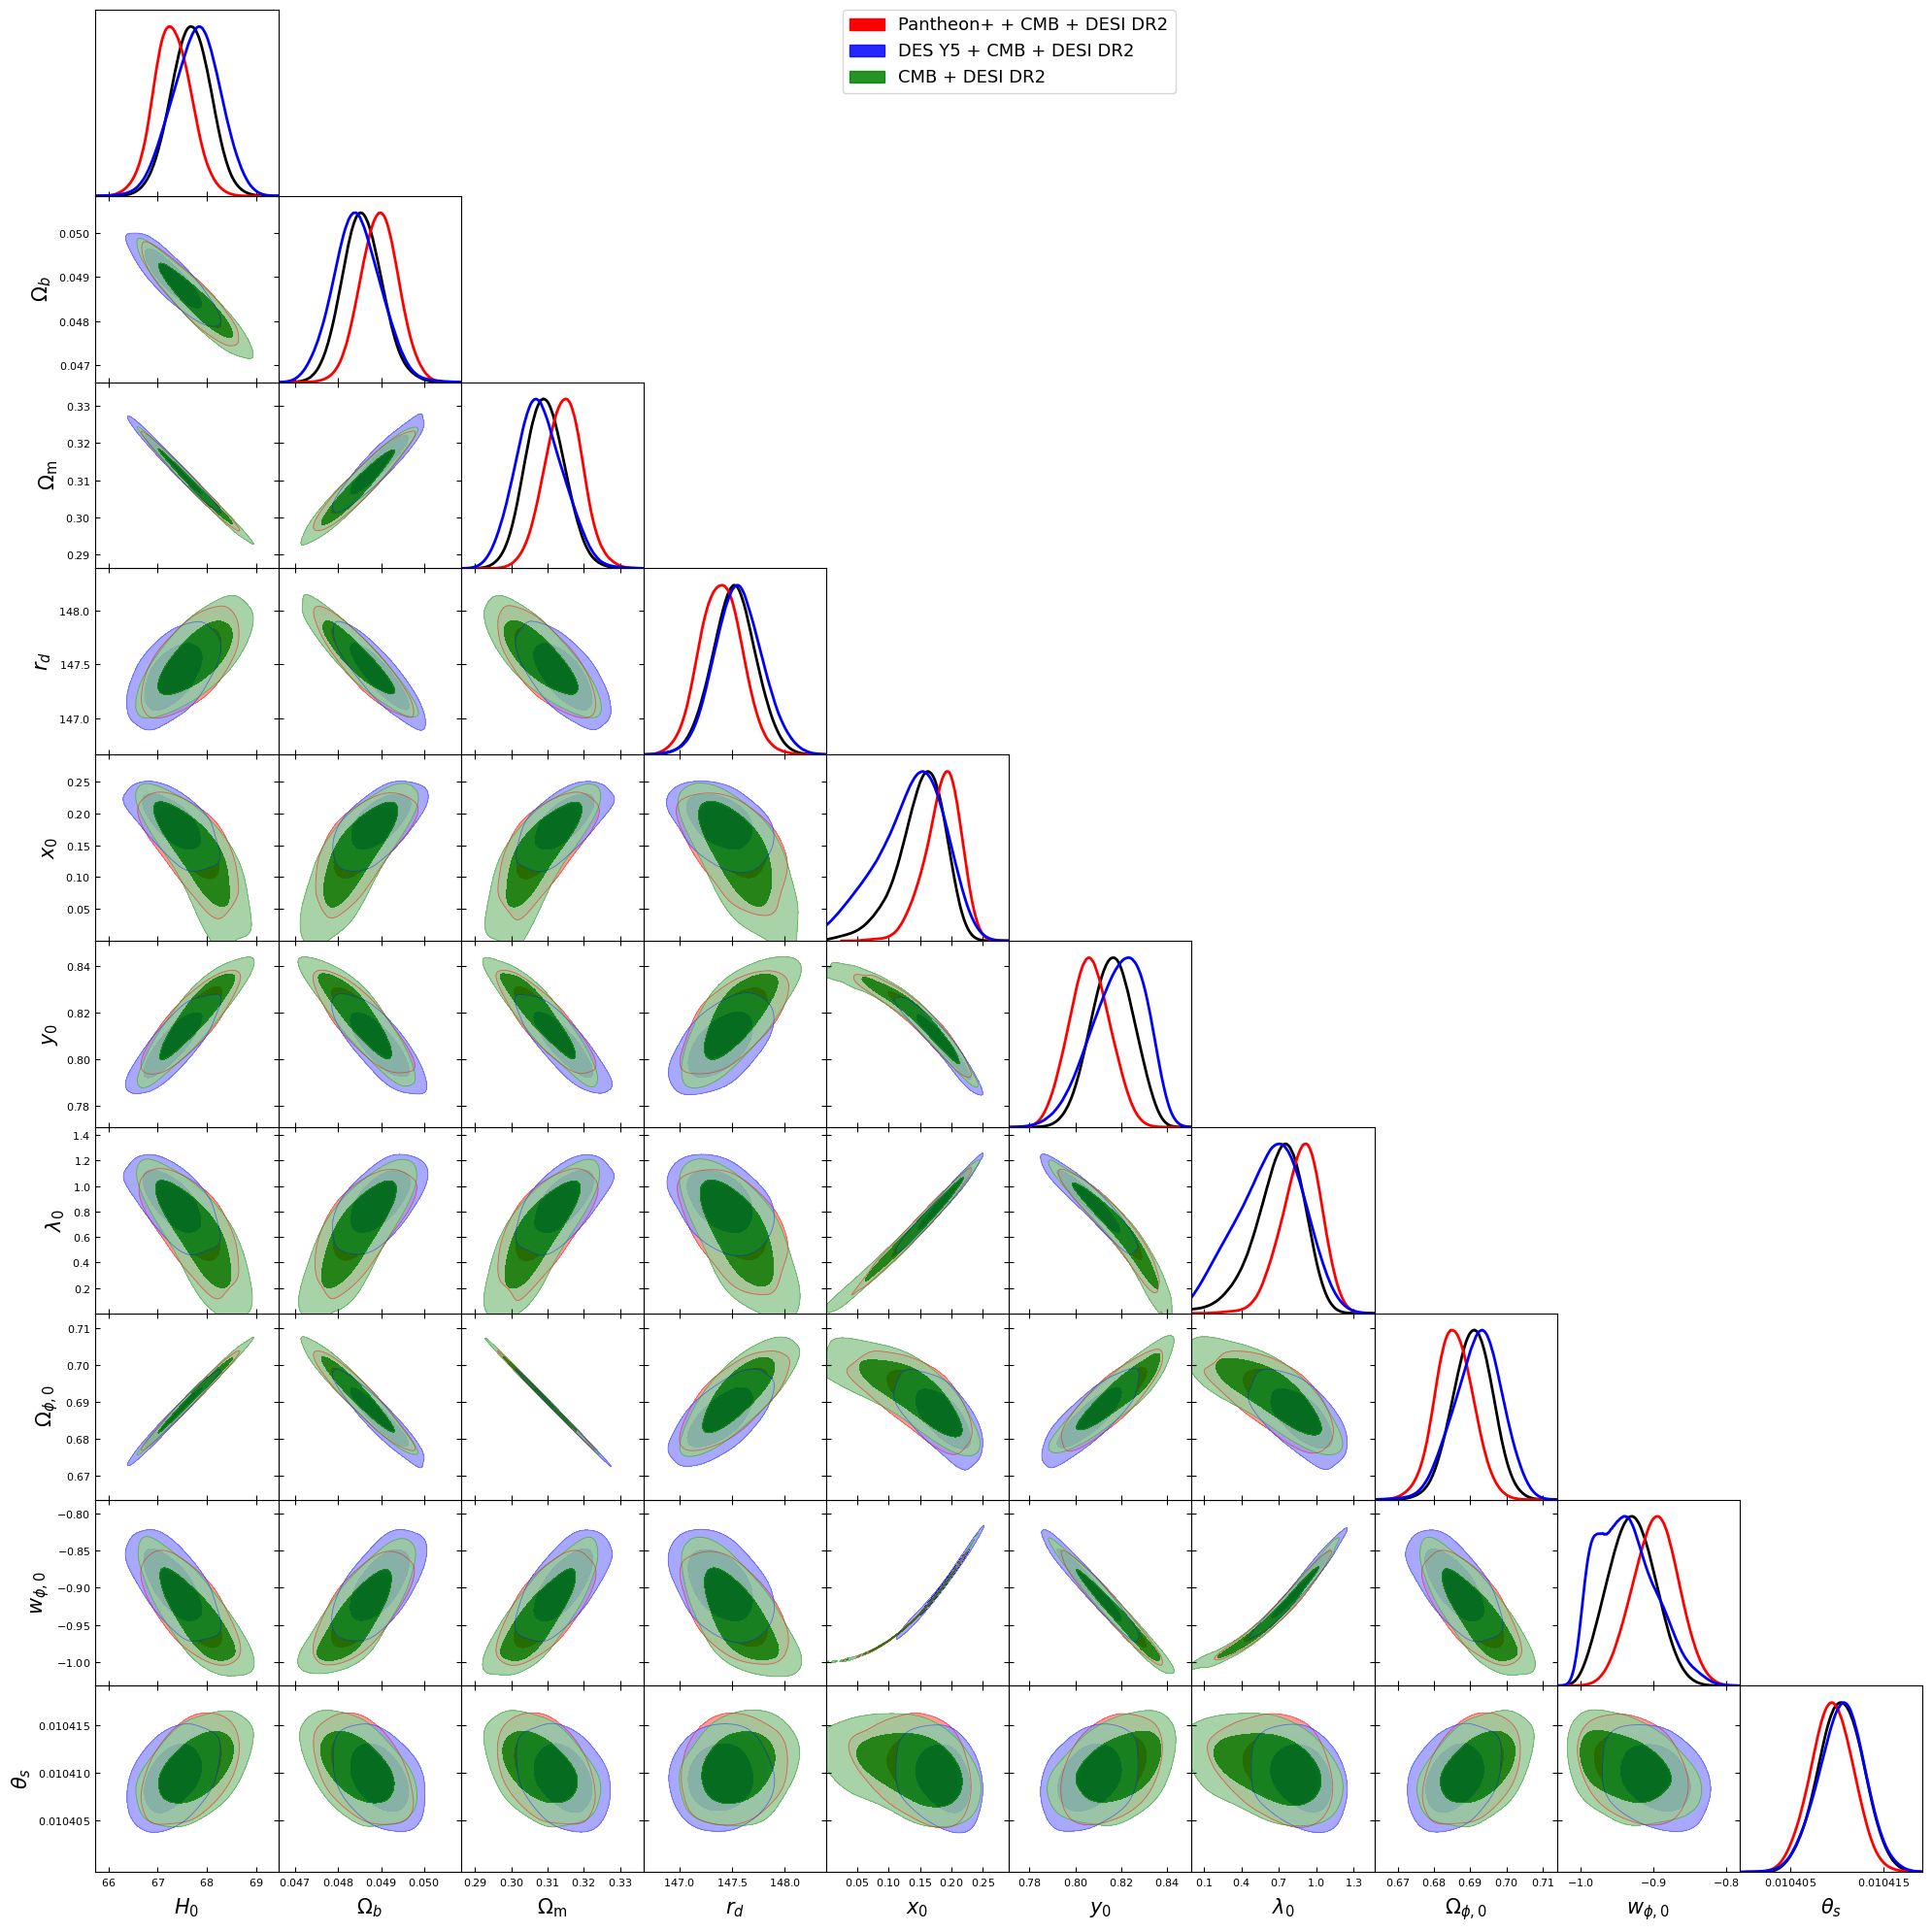


 quintessence Model: Information Criteria

Pantheon+ + CMB + DESI DR2
chi2_min = 1412.507
AIC      = 1424.507
BIC      = 1457.186

DES Y5 + CMB + DESI DR2
chi2_min = 1649.422
AIC      = 1661.422
BIC      = 1694.533

CMB + DESI DR2
chi2_min = 10.034
AIC      = 22.034
BIC      = 25.423

Parameter constraints for Pantheon+ + CMB + DESI DR2:
H_0 = 67.67\pm 0.41
\Omega_b = 0.04856\pm 0.00047
\Omega_\mathrm{m} = 0.3094\pm 0.0055
r_d = 147.52\pm 0.21
x_0 = 0.151^{+0.044}_{-0.028}
y_0 = 0.8162\pm 0.0093
\lambda_0 = 0.70^{+0.23}_{-0.16}
\Omega_{\phi,0} = 0.6906\pm 0.0055
w_{\phi,0} = -0.929\pm 0.032
\theta_s = 0.0104104\pm 0.0000024

Parameter constraints for DES Y5 + CMB + DESI DR2:
H_0 = 67.30\pm 0.38
\Omega_b = 0.04896\pm 0.00044
\Omega_\mathrm{m} = 0.3144\pm 0.0053
r_d = 147.39\pm 0.20
x_0 = 0.186^{+0.033}_{-0.023}
y_0 = 0.8063\pm 0.0089
\lambda_0 = 0.88^{+0.18}_{-0.14}
\Omega_{\phi,0} = 0.6856\pm 0.0053
w_{\phi,0} = -0.897\pm 0.031
\theta_s = 0.0104095\pm 0.0000023

Parameter constraints 

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ============================================================
# 1. Path to quintessence Cobaya chains
# ============================================================

path_prefix = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"

sets = [
    "set1_PP_CMB_DESI",
    "set2_DESY5_CMB_DESI",
    "set3_CMB_DESI"
]

labels = [
    "Pantheon+ + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

samples_quintessence = []

# ============================================================
# 2. Load MCMC samples safely
# ============================================================

for s_name in sets:
    full_path = path_prefix + s_name
    if os.path.exists(full_path + ".1.txt"):
        samples_quintessence.append(
            loadMCSamples(full_path, settings={'ignore_rows': 0.3})
        )
    else:
        print(f"Warning: Files for {s_name} not found at {full_path}")

if len(samples_quintessence) == 0:
    raise RuntimeError("No quintessence samples were loaded. Check Cobaya outputs.")

# ============================================================
# 3. Parameters to plot (quintessence)
# ============================================================

params = [
    "H0", "Omegab0", "Omegam0", "rd",
    "x0", "y0", "lambda0", "Omega_phi0",
    "w_phi0", "theta_s"
]

# ============================================================
# 4. Triangle plot
# ============================================================

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_quintessence,
    params,
    filled=True,
    legend_labels=labels[:len(samples_quintessence)],
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig(
    "quintessence_results_comparison.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 5. Robust chi-square extraction
# ============================================================

def get_chi2_min(samples):
    """
    Robust extraction of chi2_min from GetDist samples.
    Works across Cobaya/GetDist versions.
    """
    p = samples.getParams()

    if hasattr(p, "chi2"):
        return np.min(p.chi2)

    elif hasattr(p, "minusloglike"):
        return 2.0 * np.min(p.minusloglike)

    elif hasattr(p, "minuslogpost"):
        return 2.0 * np.min(p.minuslogpost)

    else:
        raise RuntimeError(
            "No chi2-like quantity found in the chain.\n"
            "Inspect with: samples.getParams().getParamNames().list()"
        )

# ============================================================
# 6. Model complexity and data size
# ============================================================

# Number of free parameters in quintessence
# (count ONLY sampled parameters, not derived ones)
k_quintessence = 6   # adjust if your sampling differs

# Number of data points for each dataset
N_values = {
    "Pantheon+ + CMB + DESI DR2": 1701 + 0 + 13,   # 1717
    "DES Y5 + CMB + DESI DR2":   1829 + 0 + 13,   # 1845
    "CMB + DESI DR2":            0 + 13           # 16
}

# ============================================================
# 7. Compute chi2_min, AIC, BIC
# ============================================================

print("\n==============================================")
print(" quintessence Model: Information Criteria")
print("==============================================")

results = []

for s, label in zip(samples_quintessence, labels):

    chi2_min = get_chi2_min(s)
    # loglikes = s.loglikes
    # chi2_min = -2.0 * np.max(loglikes)
    N = N_values[label]

    AIC = chi2_min + 2 * k_quintessence
    BIC = chi2_min + k_quintessence * np.log(N)

    results.append((label, chi2_min, AIC, BIC))

    print(f"\n{label}")
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")

# ============================================================
# 8. Save results to files
# ============================================================

# ---- Text file ----
with open("quintessence_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("quintessence_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 9. Print selected parameter constraints
# ============================================================
params = [
    "H0", "Omegab0", "Omegam0", "rd",
    "x0", "y0", "lambda0", "Omega_phi0",
    "w_phi0", "theta_s"
]

for s, l in zip(samples_quintessence, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('H0', limit=1))
    print(s.getInlineLatex('Omegab0', limit=1))
    print(s.getInlineLatex('Omegam0', limit=1))
    print(s.getInlineLatex('rd', limit=1))
    print(s.getInlineLatex('x0', limit=1))
    print(s.getInlineLatex('y0', limit=1))
    print(s.getInlineLatex('lambda0', limit=1))
    print(s.getInlineLatex('Omega_phi0', limit=1))
    print(s.getInlineLatex('w_phi0', limit=1))
    print(s.getInlineLatex('theta_s', limit=1))

In [5]:
import numpy as np
import os
from getdist import loadMCSamples

# ============================================================
# 1. Configuration & Model Complexity
# ============================================================
lcdm_path = "/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_"
quintessence_path = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"

sets = ["set1_PP_CMB_DESI", "set2_DESY5_CMB_DESI", "set3_CMB_DESI"]
labels = ["Pantheon+ + CMB + DESI DR2", "DES Y5 + CMB + DESI DR2", "CMB + DESI DR2"]

# Number of free parameters (sampled parameters)
k_lcdm = 4    
k_quintessence = 6

# Number of data points (N)
N_values = {
    "Pantheon+ + CMB + DESI DR2": 1717-3,
    "DES Y5 + CMB + DESI DR2":    1845-3,
    "CMB + DESI DR2":             16-3
}

# ============================================================
# 2. Robust Chi-Square Extraction
# ============================================================
def get_chi2_min(samples):
    p = samples.getParams()
    if hasattr(p, "chi2"):
        return np.min(p.chi2)
    elif hasattr(p, "minusloglike"):
        return 2.0 * np.min(p.minusloglike)
    elif hasattr(p, "minuslogpost"):
        return 2.0 * np.min(p.minuslogpost)
    else:
        raise RuntimeError("No chi2 found in chain.")

# ============================================================
# 3. Calculation and Comparison
# ============================================================
results = []

print(f"{'Dataset':<28} | {'Model':<8} | {'chi2_min':<10} | {'AIC':<10} | {'BIC':<10}")
print("-" * 85)

for s_name, label in zip(sets, labels):
    try:
        # Load both sets of samples
        s_l = loadMCSamples(lcdm_path + s_name, settings={'ignore_rows': 0.3})
        s_q = loadMCSamples(quintessence_path + s_name, settings={'ignore_rows': 0.3})
        
        # Calculate chi2_min
        c2_l = get_chi2_min(s_l)
        c2_q = get_chi2_min(s_q)
        N = N_values[label]

        # LCDM Metrics
        aic_l = c2_l + 2 * k_lcdm
        bic_l = c2_l + k_lcdm * np.log(N)

        # quintessence Metrics
        aic_q = c2_q + 2 * k_quintessence
        bic_q = c2_q + k_quintessence * np.log(N)

        # Differences (quintessence - LCDM)
        d_c2 = c2_q - c2_l
        d_aic = aic_q - aic_l
        d_bic = bic_q - bic_l
        
        # Store for table
        results.append({
            'label': label,
            'c2_l': c2_l, 'aic_l': aic_l, 'bic_l': bic_l,
            'c2_q': c2_q, 'aic_q': aic_q, 'bic_q': bic_q,
            'd_c2': d_c2, 'd_aic': d_aic, 'd_bic': d_bic
        })

        # Print console summary
        print(f"{label:<28} | LCDM     | {c2_l:<10.2f} | {aic_l:<10.2f} | {bic_l:<10.2f}")
        print(f"{'':<28} | quintessence  | {c2_q:<10.2f} | {aic_q:<10.2f} | {bic_q:<10.2f}")
        print(f"{'':<28} | Delta    | {d_c2:<10.2f} | {d_aic:<10.2f} | {d_bic:<10.2f}")
        print("-" * 85)

    except Exception as e:
        print(f"Error processing {label}: {e}")

# ============================================================
# 4. Generate Comprehensive LaTeX Table
# ============================================================
with open("model_comparison_full.tex", "w") as f:
    f.write(r"\begin{tabular}{llcccccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & Model & $\chi^2_{\min}$ & AIC & BIC & $\Delta\chi^2$ & $\Delta$AIC & $\Delta$BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    
    for r in results:
        # LCDM Row - Using fr"" to avoid SyntaxWarning with \Lambda
        f.write(fr"{r['label']} & $\Lambda$CDM & {r['c2_l']:.2f} & {r['aic_l']:.2f} & {r['bic_l']:.2f} & -- & -- & -- \\" + "\n")
        # quintessence Row
        f.write(f" & quintessence & {r['c2_q']:.2f} & {r['aic_q']:.2f} & {r['bic_q']:.2f} & {r['d_c2']:.2f} & {r['d_aic']:.2f} & {r['d_bic']:.2f} \\\\\n")
        f.write(r"\hline" + "\n")
        
    f.write(r"\end{tabular}" + "\n")

print("\nFull LaTeX table saved to 'model_comparison_full.tex'")

Dataset                      | Model    | chi2_min   | AIC        | BIC       
-------------------------------------------------------------------------------------
Pantheon+ + CMB + DESI DR2   | LCDM     | 1419.94    | 1427.94    | 1449.72   
                             | quintessence  | 1412.51    | 1424.51    | 1457.19   
                             | Delta    | -7.43      | -3.43      | 7.46      
-------------------------------------------------------------------------------------
DES Y5 + CMB + DESI DR2      | LCDM     | 1663.82    | 1671.82    | 1693.90   
                             | quintessence  | 1649.42    | 1661.42    | 1694.53   
                             | Delta    | -14.40     | -10.40     | 0.63      
-------------------------------------------------------------------------------------
CMB + DESI DR2               | LCDM     | 13.89      | 21.89      | 24.15     
                             | quintessence  | 10.03      | 22.03      | 25.42     
                

In [6]:
import numpy as np
from getdist import loadMCSamples

# ============================================================
# CONFIGURATION
# ============================================================

MODELS = {
    "lcdm": {
        "path": "/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_",
        "k": 4
    },
    "quintessence": {
        "path": "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_",
        "k": 6
    }
}

DATASETS = {
    "set1_PP_CMB_DESI": "Pantheon+ + CMB + DESI DR2",
    "set2_DESY5_CMB_DESI": "DES Y5 + CMB + DESI DR2",
    "set3_CMB_DESI": "CMB + DESI DR2"
}

N_DATA = {
    "set1_PP_CMB_DESI": 1701 + 13 + 0,
    "set2_DESY5_CMB_DESI": 1829 + 13 + 0,
    "set3_CMB_DESI": 13 + 0
}

IGNORE_ROWS = 0.3 

# ============================================================
# COMPUTATION
# ============================================================

results = {}

for dataset, label in DATASETS.items():
    results[dataset] = {}

    for model, cfg in MODELS.items():
        try:
            # Fixed the keyword argument to 'no_cache'
            samples = loadMCSamples(
                cfg["path"] + dataset,
                settings={"ignore_rows": IGNORE_ROWS},
                no_cache=True
            )

            # Extract log-likelihoods
            loglikes = samples.loglikes
            valid_loglikes = loglikes[np.isfinite(loglikes)]
            
            # chi2 = -2 * max(log-likelihood)
            chi2_min = -2.0 * np.max(valid_loglikes)

            k = cfg["k"]
            N = N_DATA[dataset]

            AIC = chi2_min + 2 * k
            BIC = chi2_min + k * np.log(N)

            results[dataset][model] = {
                "chi2_min": chi2_min,
                "AIC": AIC,
                "BIC": BIC
            }
        except Exception as e:
            print(f"Error loading {model} for {dataset}: {e}")

# ============================================================
# Δ COMPARISON & FORMATTED OUTPUT
# ============================================================

print("\n" + "="*85)
print(f"{'DATASET':<30} | {'MODEL':<10} | {'chi2_min':>10} | {'AIC':>10} | {'BIC':>10}")
print("-" * 85)

for dataset, label in DATASETS.items():
    # Only proceed if both models loaded successfully for this dataset
    if "lcdm" in results[dataset] and "quintessence" in results[dataset]:
        res_l = results[dataset]["lcdm"]
        res_q = results[dataset]["quintessence"]

        # Differences (quintessence - LCDM)
        d_chi2 = res_q["chi2_min"] - res_l["chi2_min"]
        d_AIC  = res_q["AIC"] - res_l["AIC"]
        d_BIC  = res_q["BIC"] - res_l["BIC"]

        # Print Raw Values
        print(f"{label:<30} | {'LCDM':<10} | {res_l['chi2_min']:10.2f} | {res_l['AIC']:10.2f} | {res_l['BIC']:10.2f}")
        print(f"{'':<30} | {'quintessence':<10} | {res_q['chi2_min']:10.2f} | {res_q['AIC']:10.2f} | {res_q['BIC']:10.2f}")
        
        # Print Deltas
        print(f"{'':<30} | {'Delta':<10} | {d_chi2:10.2f} | {d_AIC:10.2f} | {d_BIC:10.2f}")
        
        # Basic interpretation based on AIC
        pref = "LCDM" if d_AIC > 0 else "quintessence"
        print(f"Result: Preference for {pref} (Delta_AIC = {d_AIC:+.2f})")
        print("-" * 85)

/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set1_PP_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set1_PP_CMB_DESI.1.txt
Removed 0.3 as burn in


/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set2_DESY5_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set2_DESY5_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set3_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set3_CMB_DESI.1.txt
Removed 0.3 as burn in

DATASET                        | MODEL      |   chi2_min |        AIC |        BIC
-------------------------------------------------------------------------------------
Pantheon+ + CMB + DESI DR2     | LCDM       |   -1439.12 |   -1431.12 |   -1409.34
                               | quintessence |   -1440.19 |   -1428.19 |   -1395.52
                               | Delta      |      -1.07 |       2.93 |      13.82
Result: Preference for LCDM (Delta_AIC = +2.93)
-----

/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set1_PP_CMB_DESI.1.txt
Removed 0.3 as burn in


/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set2_DESY5_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_set3_CMB_DESI.1.txt


Removed 0.3 as burn in


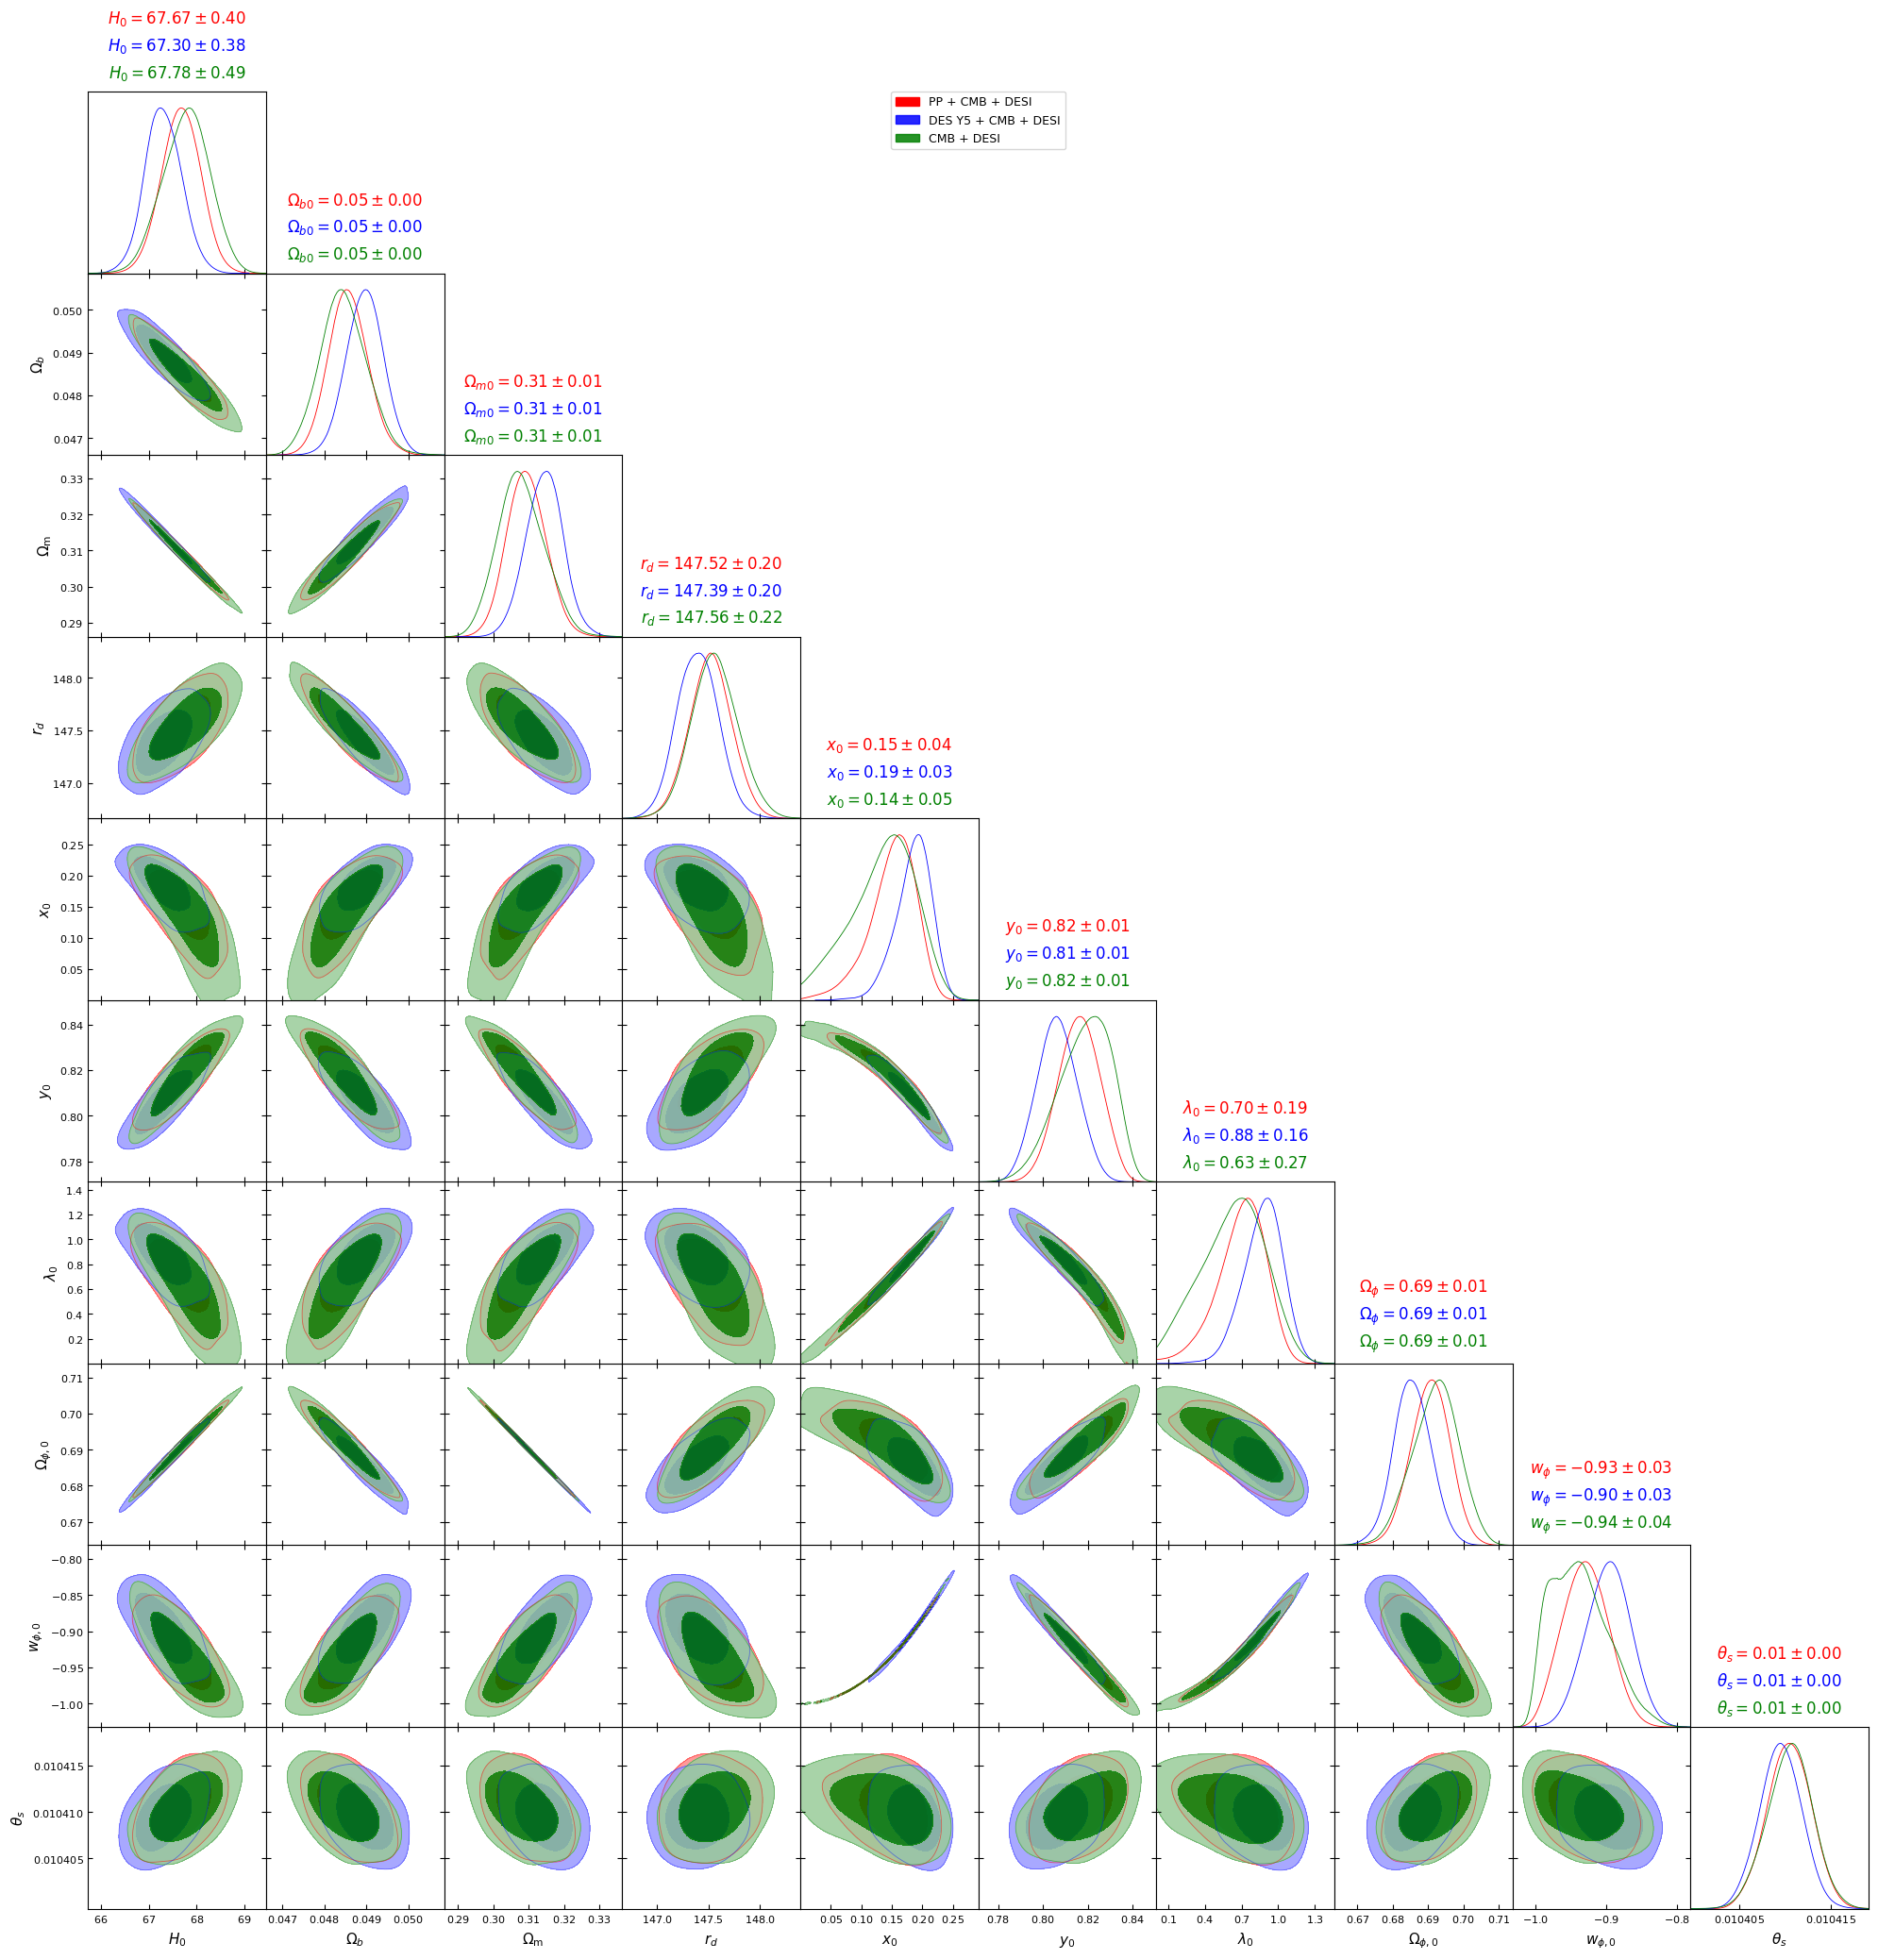

In [7]:
from getdist import loadMCSamples, plots
import matplotlib.pyplot as plt
import os

# 1. Setup paths
path_prefix = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"
sets = ["set1_PP_CMB_DESI", "set2_DESY5_CMB_DESI", "set3_CMB_DESI"]
labels = ['PP + CMB + DESI', 'DES Y5 + CMB + DESI', 'CMB + DESI']
colors = ['red', 'blue', 'green']
samples = []

# 2. Load samples
analysis_settings = {'ignore_rows': 0.3, 'smooth_scale_2d': 2.5}

for s_name in sets:
    full_path = path_prefix + s_name
    if os.path.exists(full_path + ".1.txt"):
        samples.append(loadMCSamples(full_path, settings=analysis_settings))

# Define your display labels
tex_labels = {
    "H0": r"H_0",
    "Omegab0": r"\Omega_{b0}",
    "Omegam0": r"\Omega_{m0}",
    "rd": r"r_{d}",
    "x0": r"x_{0}",
    "y0": r"y_{0}",
    "lambda0": r"\lambda_{0}",
    "Omega_phi0": r"\Omega_{\phi}",
    "w_phi0": r"w_{\phi}",
    "theta_s": r"\theta_{s}"
}

params = ["H0", "Omegab0", "Omegam0", "rd",
    "x0", "y0", "lambda0", "Omega_phi0",
    "w_phi0", "theta_s"]

# 3. Initialize Plotter
g = plots.get_subplot_plotter()

if len(samples) > 0:
    g.triangle_plot(
        samples, 
        params, 
        filled=True, 
        legend_labels=labels,
        contour_colors=colors,
        title_limit=False 
    )
    
    # 4. MANUALLY CONSTRUCT COLORED TITLES WITH PARAMETER NAMES
    for i, p in enumerate(params):
        ax = g.subplots[i, i]
        if ax is not None:
            display_name = tex_labels.get(p, p)
            
            # Starting vertical position (relative to the subplot)
            # 1.0 is the top edge of the plot
            y_pos = 1.35 
            line_spacing = 0.18
            
            for j, samp in enumerate(samples):
                marge = samp.getMargeStats().parWithName(p)
                mean = marge.mean
                # 1-sigma error
                err = (marge.limits[0].upper - marge.limits[0].lower) / 2
                
                # Construct the specific string: "H0 = 67.64 +/- 0.39"
                res_str = rf"${display_name} = {mean:.2f} \pm {err:.2f}$"
                
                # Add text to the plot
                ax.text(0.5, y_pos, res_str, 
                        transform=ax.transAxes, 
                        ha='center', 
                        va='bottom',
                        fontsize=12, 
                        color=colors[j], 
                        fontweight='bold')
                
                # Move the next line of text down
                y_pos -= 0.15

    # 5. Final Adjustments
    # Increase hspace to accommodate the 3-line titles between rows
    plt.subplots_adjust(top=0.85, hspace=0.5)
    
    plt.savefig("quintessence_cosmological_param.png", bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("No samples found. Check your file paths.")


 Information Criteria (quintessence Model)

Pantheon + + CMB + DESI DR2
chi2_min = 1412.507
AIC      = 1428.507
BIC      = 1472.093

DES Y5 + CMB + DESI DR2
chi2_min = 1649.422
AIC      = 1665.422
BIC      = 1709.583

CMB + DESI DR2
chi2_min = 10.034
AIC      = 26.034
BIC      = 32.214


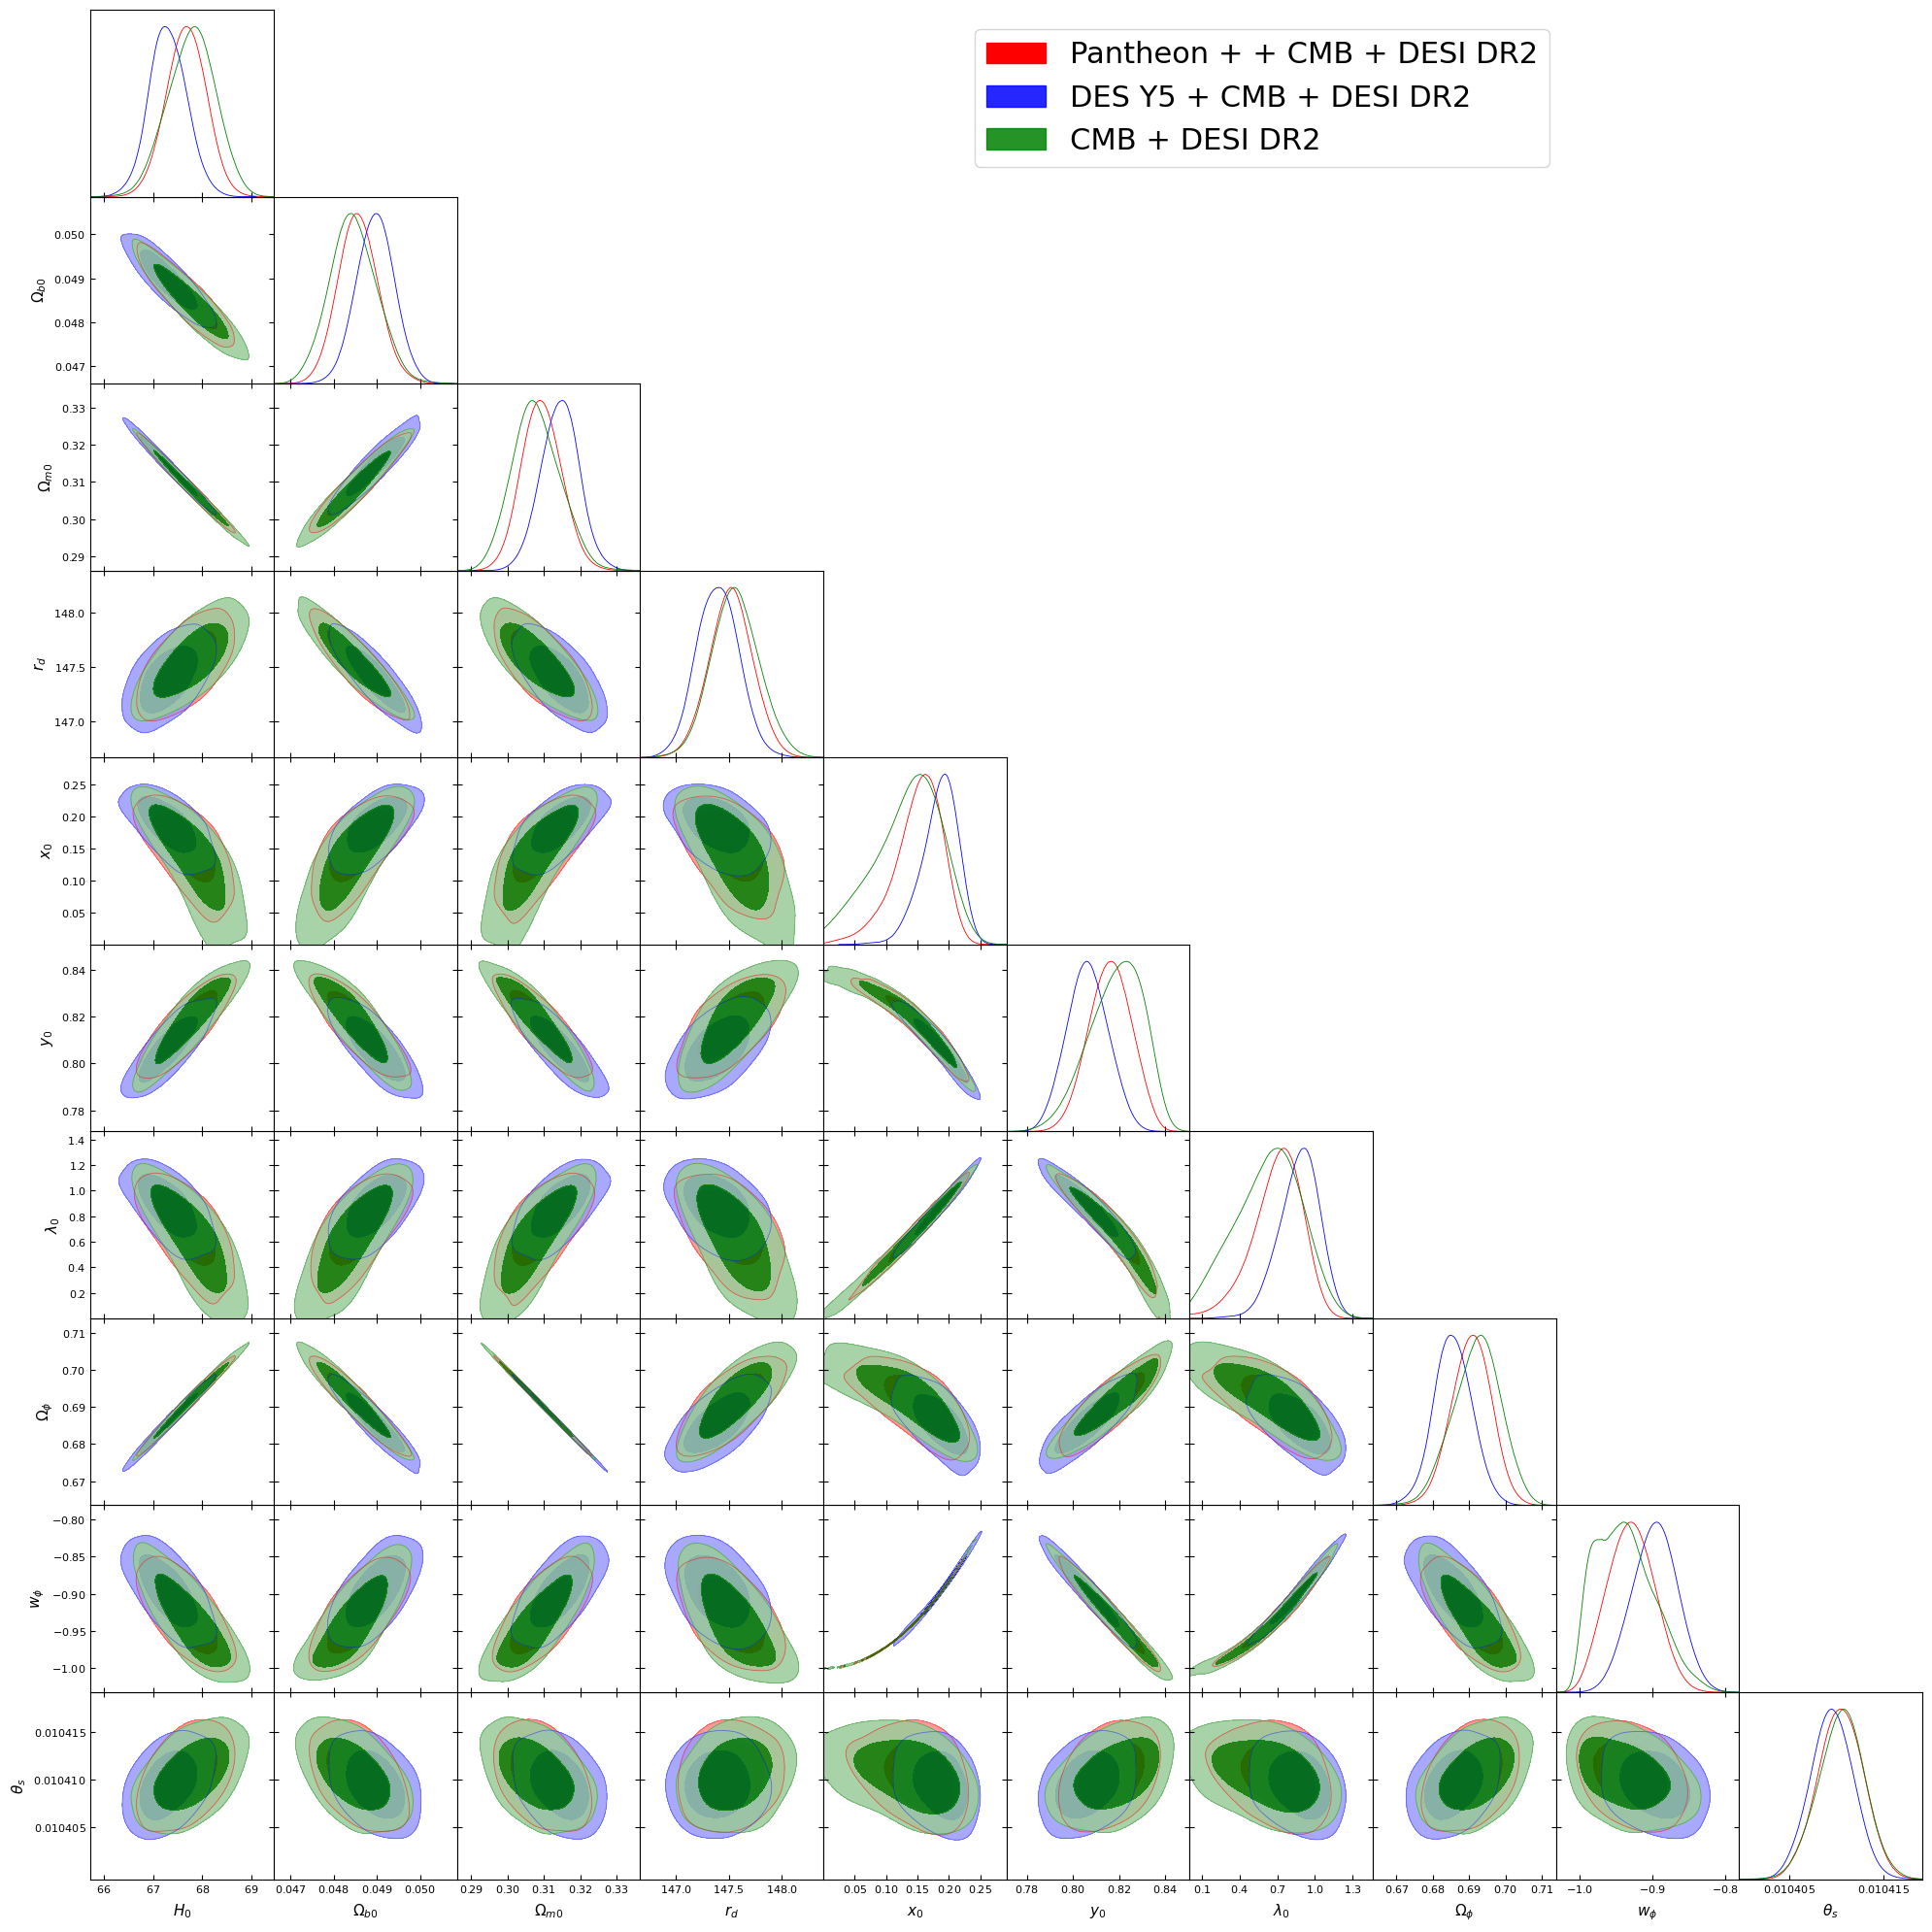

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ============================================================
# 1. Path to Cobaya chains (must match Cobaya 'output' prefix)
# ============================================================

path_prefix = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"

sets = [
    "set1_PP_CMB_DESI",
    "set2_DESY5_CMB_DESI",
    "set3_CMB_DESI"
]

labels = [
    "Pantheon + + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

samples = []

# ============================================================
# 2. Load MCMC samples safely
# ============================================================

for s_name in sets:
    full_path = path_prefix + s_name
    if os.path.exists(full_path + ".1.txt"):
        s = loadMCSamples(
            full_path,
            settings={"ignore_rows": 0.3}
        )
        samples.append(s)
    else:
        print(f"Warning: Chain files not found for {s_name}")

if len(samples) == 0:
    raise RuntimeError("No samples loaded. Check Cobaya output paths.")



# ------------------------------------------------------------
# SAFE PARAMETER LABEL MODIFICATION (IN-PLACE)
# ------------------------------------------------------------
latex_labels = {
    "H0": r"H_0",
    "Omegab0": r"\Omega_{b0}",
    "Omegam0": r"\Omega_{m0}",
    "rd": r"r_{d}",
    "x0": r"x_{0}",
    "y0": r"y_{0}",
    "lambda0": r"\lambda_{0}",
    "Omega_phi0": r"\Omega_{\phi}",
    "w_phi0": r"w_{\phi}",
    "theta_s": r"\theta_{s}"
}

for s in samples:
    for p in s.paramNames.names:
        if p.name in latex_labels:
            p.label = latex_labels[p.name]



# ============================================================
# 3. Parameters to plot (must match Cobaya names)
# ============================================================

params = [
    "H0", "Omegab0", "Omegam0", "rd",
    "x0", "y0", "lambda0", "Omega_phi0",
    "w_phi0", "theta_s"
]

# ============================================================
# 4. AIC / BIC computation function
# ============================================================

def compute_ic(samples, k, N):
    p = samples.getParams()

    # Case 1: total chi2 explicitly stored
    if hasattr(p, "chi2"):
        chi2_min = np.min(p.chi2)

    # Case 2: Cobaya-style minusloglike
    elif hasattr(p, "minusloglike"):
        chi2_min = 2 * np.min(p.minusloglike)

    # Case 3: minuslogpost (prior contribution negligible at best-fit)
    elif hasattr(p, "minuslogpost"):
        chi2_min = 2 * np.min(p.minuslogpost)

    else:
        raise RuntimeError(
            "No chi2-like parameter found in chains. "
            "Check available parameters with "
            "samples.getParams().getParamNames().list()"
        )

    AIC = chi2_min + 2 * k
    BIC = chi2_min + k * np.log(N)

    return chi2_min, AIC, BIC


# ============================================================
# 5. Model complexity and data size
# ============================================================

# Number of free parameters in quintessence
k = 8

# Number of data points for each dataset
# (MUST match datasets exactly)
N_values = [
    1717,  # Pantheon+ (1701) + CMB (3) + DESI DR2 (13)
    1845,  # DES Y5 (~1829) + CMB (3) + DESI DR2 (13)
    16     # CMB (3) + DESI DR2 (13)
]

# ============================================================
# 6. Print AIC / BIC table
# ============================================================

print("\n==============================================")
print(" Information Criteria (quintessence Model)")
print("==============================================")

results = []

for s, label, N in zip(samples, labels, N_values):
    chi2, aic, bic = compute_ic(s, k, N)
    results.append((label, chi2, aic, bic))

    print(f"\n{label}")
    print(f"chi2_min = {chi2:.3f}")
    print(f"AIC      = {aic:.3f}")
    print(f"BIC      = {bic:.3f}")

# ============================================================
# 7. Triangle plot
# ============================================================

g = plots.get_subplot_plotter()
g.settings.legend_fontsize = 25

# Define your color list once to keep it consistent
my_colors = ["red", "blue", "green"]

g.triangle_plot(
    samples,
    params,
    filled=True,
    legend_labels=labels[:len(samples)],
    contour_colors=my_colors,
    # Add 'color' to line_args to ensure 1D plots match 2D contours
    line_args=[
        {"ls": "-", "color": my_colors[0]}, 
        {"ls": "-", "color": my_colors[1]}, 
        {"ls": "-", "color": my_colors[2]}
    ]
)

# ---- LEGEND SHIFT (Matplotlib, version-safe) ----
fig = plt.gcf()
leg = fig.legends[0] if fig.legends else None
if leg is not None:
    leg.set_bbox_to_anchor((0.65, 0.98))

plt.savefig(
    "quintessence_results_final.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 8. (Optional) Save IC results to text file
# ============================================================

with open("quintessence_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set1_PP_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set2_DESY5_CMB_DESI.1.txt
Removed 0.3 as burn in
/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_set3_CMB_DESI.1.txt
Removed 0.3 as burn in


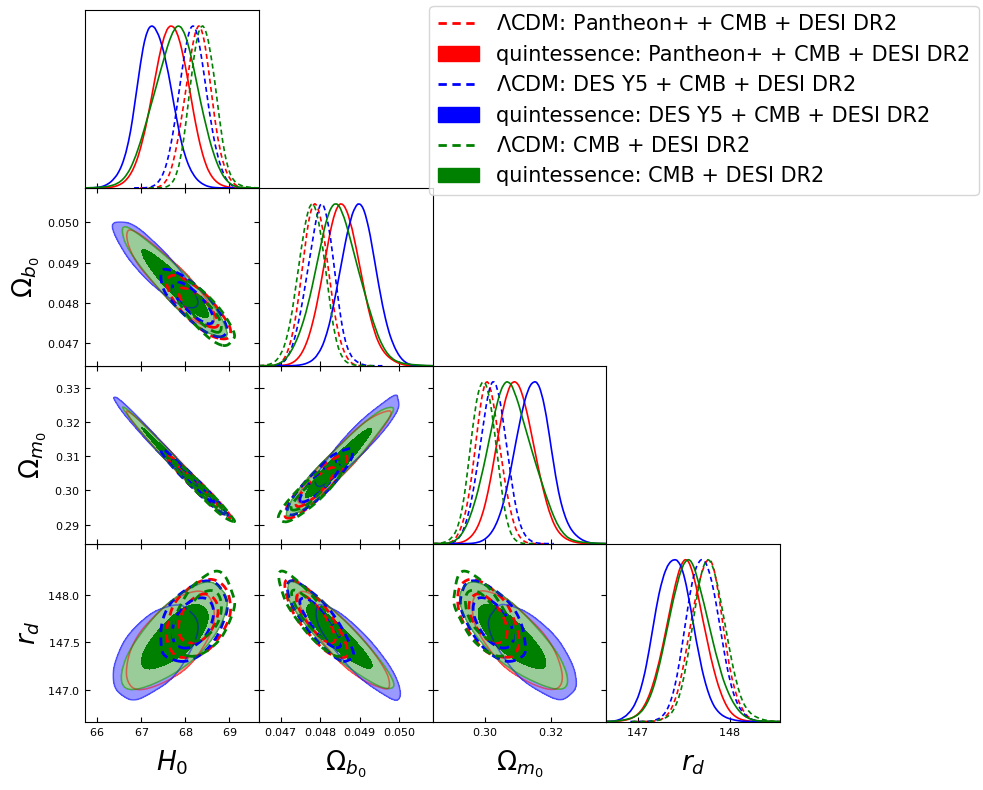

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots

# ------------------------------------------------------------
# Matplotlib tick sizes
# ------------------------------------------------------------
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
cpl_prefix    = "/Users/prasantasahoo/Documents/cobaya_project/cpl/chains/cpl/cpl_"
lcdm_prefix    = "/Users/prasantasahoo/Documents/cobaya_project/lcdm/chains/lcdm/lcdm_"
quintessence_prefix = "/Users/prasantasahoo/Documents/cobaya_project/Quintessence_for_Cobaya/chains/quintessence/quintessence_"

sets = [
    "set1_PP_CMB_DESI",
    "set2_DESY5_CMB_DESI",
    "set3_CMB_DESI"
]

dataset_labels = [
    "Pantheon+ + CMB + DESI DR2",
    "DES Y5 + CMB + DESI DR2",
    "CMB + DESI DR2"
]

# ------------------------------------------------------------
# Load samples
# ------------------------------------------------------------
samples = []
legend_labels = []
line_args = []
contour_colors = []
filled_list = []
ls_list = []

colors = ["red", "blue", "green"]

for s, label, col in zip(sets, dataset_labels, colors):

    # # cpl: Unfilled, dotted
    # cpl = loadMCSamples(cpl_prefix + s, settings={"ignore_rows": 0.3})
    # samples.append(cpl)
    # legend_labels.append(r"CPL: " + label)
    # line_args.append({"ls": ":", "lw": 2, "color": col})
    # contour_colors.append(col)
    # filled_list.append(False)
    # ls_list.append(":")

    # ΛCDM: Unfilled, dotted
    lcdm = loadMCSamples(lcdm_prefix + s, settings={"ignore_rows": 0.3})
    samples.append(lcdm)
    legend_labels.append(r"$\Lambda$CDM: " + label)
    line_args.append({"ls": "--", "lw": 2, "color": col})
    contour_colors.append(col)
    filled_list.append(False)
    ls_list.append("--")

    # quintessence: Filled, solid
    quintessence = loadMCSamples(quintessence_prefix + s, settings={"ignore_rows": 0.3})
    samples.append(quintessence)
    legend_labels.append("quintessence: " + label)
    line_args.append({"ls": "-", "lw": 2, "color": col})
    contour_colors.append(col)
    filled_list.append(True)
    ls_list.append("-")

# ------------------------------------------------------------
# SAFE PARAMETER LABEL MODIFICATION (IN-PLACE)
# ------------------------------------------------------------
latex_labels = {
    "H0": r"H_{0}",
    "Omegab0": r"\Omega_{b_0}",
    "Omegam0": r"\Omega_{m_0}",
    "rd": r"r_{d}"
}

for s in samples:
    for p in s.paramNames.names:
        if p.name in latex_labels:
            p.label = latex_labels[p.name]

# ------------------------------------------------------------
# Parameters (internal names ONLY)
# ------------------------------------------------------------
params = ["H0", "Omegab0", "Omegam0", "rd"]

# ------------------------------------------------------------
# Create Triangle Plot
# ------------------------------------------------------------
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 18
g.settings.axes_labelsize  = 22
g.settings.lab_fontsize    = 22
g.settings.alpha_filled_add = 1.0

# 2D contour line width
g.settings.lw_contour = 1.2

# Legend position
g.settings.legend_loc = "upper left"

g.triangle_plot(
    samples,
    params,
    filled=filled_list,
    legend_labels=legend_labels,
    contour_colors=contour_colors,
    line_args=line_args,
    contour_ls=ls_list,
    contour_lws=[2.0] * len(samples)
)

# ------------------------------------------------------------
# Adjust 1D marginal line widths
# ------------------------------------------------------------
fig = plt.gcf()

for ax in fig.axes:
    if ax.get_xlim() == ax.get_ylim():
        continue
    for line in ax.get_lines():
        line.set_linewidth(1.2)

# ------------------------------------------------------------
# Legend shift (Matplotlib-safe)
# ------------------------------------------------------------
leg = fig.legends[0] if fig.legends else None
if leg is not None:
    leg.set_bbox_to_anchor((0.88, 0.98))

# ------------------------------------------------------------
# Save & show
# ------------------------------------------------------------
plt.savefig(
    "lcdm_dotted_vs_quintessence_filled.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()